<a href="https://colab.research.google.com/github/Andrija110/DungeonsOfChaos/blob/main/Vjez%CC%8Cbe_5_direktna_inverzna_kinematika_vizualizacija.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Direktna i Inverzna Kinematika Robota

U ovom notebooku prolazimo kroz izračun **direktne** i **inverzne kinematike** robotskog manipulatora.
Koristimo **NumPy**, **Sympy** za simboličku matematiku te **SciPy** za numeričko rješavanje jednadžbi.

## 1. Uvoz potrebnih biblioteka

In [ ]:
import numpy as np
from sympy import *

## 2. Definicija simboličkih varijabli
Definiramo simbole za kuteve zglobova (`q1`–`q6`) i parametre robota (...).

In [ ]:
q1, q2, q3, q4, q5, q6 = symbols('q1 q2 q3 q4 q5 q6')
d1, a2, a3, d4, d6 = symbols('d1 a2 a3 d4 d6')

## 3. Definicija Denavit-Hartenberg parametara
Za svaki zglob postavljamo vrijednosti parametara kuta `alpha`. Ovdje su vrijednosti prilagođene određenom robotu.

In [ ]:
alpha_1 = -np.pi/2
alpha_2 = 0
alpha_3 = -np.pi/2
alpha_4 = np.pi/2
alpha_5 = -np.pi/2
alpha_6 = 0

a1 = 0

## 4. Transformacijske matrice
Definiramo transformacijske matrice između susjednih zglobova koristeći trigonometrijske funkcije.

In [ ]:
T_0_1 = np.array([[cos(q1), 0, -sin(q1), 0],
                  [sin(q1), 0, cos(q1), 0],
                  [0, -1, 0, 0.29],
                  [0, 0, 0, 1]])

T_1_2 = np.array([[cos(q2), -sin(q2), 0, 0.27*cos(q2)],
                  [sin(q2), cos(q2), 0, 0.27*sin(q2)],
                  [0, 0, 1, 0],
                  [0, 0, 0, 1]])

T_2_3 = np.array([[cos(q3), 0, -sin(q3), 0.07*cos(q3)],
                  [sin(q3), 0, cos(q3), 0.07*sin(q3)],
                  [0, -1, 0, 0],
                  [0, 0, 0, 1]])

T_3_4 = np.array([[cos(q4), 0, sin(q4), 0],
                  [sin(q4), 0, -cos(q4), 0],
                  [0, 1, 0, 0.302],
                  [0, 0, 0, 1]])

T_4_5 = np.array([[cos(q5), 0, -sin(q5), 0],
                  [sin(q5), 0, cos(q5), 0],
                  [0, -1, 0, 0],
                  [0, 0, 0, 1]])

T_5_6 = np.array([[cos(q6), -sin(q6), 0, 0],
                  [sin(q6), cos(q6), 0, 0],
                  [0, 0, 1, 0.147],
                  [0, 0, 0, 1]])

## 5. Direktna kinematika
Ukupna matrica transformacije dobije se množenjem svih parcijalnih matrica.

In [ ]:
T_0_6 = T_0_1.dot(T_1_2).dot(T_2_3).dot(T_3_4).dot(T_4_5).dot(T_5_6)
T = simplify(T_0_6)

print("The full (simplified) transformation matrix:")
print(T)

The full (simplified) transformation matrix:
[[((sin(q1)*sin(q4) + cos(q1)*cos(q4)*cos(q2 + q3))*cos(q5) - sin(q5)*sin(q2 + q3)*cos(q1))*cos(q6) + (sin(q1)*cos(q4) - sin(q4)*cos(q1)*cos(q2 + q3))*sin(q6), (-(sin(q1)*sin(q4) + cos(q1)*cos(q4)*cos(q2 + q3))*cos(q5) + sin(q5)*sin(q2 + q3)*cos(q1))*sin(q6) + (sin(q1)*cos(q4) - sin(q4)*cos(q1)*cos(q2 + q3))*cos(q6), -(sin(q1)*sin(q4) + cos(q1)*cos(q4)*cos(q2 + q3))*sin(q5) - sin(q2 + q3)*cos(q1)*cos(q5), -0.147*sin(q1)*sin(q4)*sin(q5) - 0.147*sin(q5)*cos(q1)*cos(q4)*cos(q2 + q3) - 0.147*sin(q2 + q3)*cos(q1)*cos(q5) - 0.302*sin(q2 + q3)*cos(q1) + 0.27*cos(q1)*cos(q2) + 0.07*cos(q1)*cos(q2 + q3)], [((sin(q1)*cos(q4)*cos(q2 + q3) - sin(q4)*cos(q1))*cos(q5) - sin(q1)*sin(q5)*sin(q2 + q3))*cos(q6) - (sin(q1)*sin(q4)*cos(q2 + q3) + cos(q1)*cos(q4))*sin(q6), ((-sin(q1)*cos(q4)*cos(q2 + q3) + sin(q4)*cos(q1))*cos(q5) + sin(q1)*sin(q5)*sin(q2 + q3))*sin(q6) - (sin(q1)*sin(q4)*cos(q2 + q3) + cos(q1)*cos(q4))*cos(q6), (-sin(q1)*cos(q4)*cos(q2 + q3) + 

### Evaluacija matrice za nulte kuteve
Provjeravamo izgled matrice kada su svi kutevi jednaki nuli.

In [ ]:
result = T.subs({q1:0.3, q2:0, q3:0, q4:0, q5:0, q6:0})
print(result)

[[0.955336489125606, 0.29552020666134, 0, 0.324814406302706], [0.29552020666134, -0.955336489125606, 0, 0.100476870264855], [0, 0, -1, -0.159], [0, 0, 0, 1]]


## 6. Inverzna kinematika
Iz matrice transformacije izdvajamo elemente koji definiraju položaj i orijentaciju efektora (`w1`–`w6`).

In [ ]:
w1 = T_0_6[0][3]
w2 = T_0_6[1][3]
w3 = T_0_6[2][3]
w4 = T_0_6[0][2]
w5 = T_0_6[1][2]
w6 = T_0_6[2][2]

print("Jednadžbe za inverznu kinematiku:")
print(w1)
print(w2)
print(w3)
print(w4)
print(w5)
print(w6)

Jednadžbe za inverznu kinematiku:
-0.147*((-sin(q2)*sin(q3)*cos(q1) + cos(q1)*cos(q2)*cos(q3))*cos(q4) + sin(q1)*sin(q4))*sin(q5) + 0.147*(-sin(q2)*cos(q1)*cos(q3) - sin(q3)*cos(q1)*cos(q2))*cos(q5) - 0.07*sin(q2)*sin(q3)*cos(q1) - 0.302*sin(q2)*cos(q1)*cos(q3) - 0.302*sin(q3)*cos(q1)*cos(q2) + 0.07*cos(q1)*cos(q2)*cos(q3) + 0.27*cos(q1)*cos(q2)
-0.147*((-sin(q1)*sin(q2)*sin(q3) + sin(q1)*cos(q2)*cos(q3))*cos(q4) - sin(q4)*cos(q1))*sin(q5) + 0.147*(-sin(q1)*sin(q2)*cos(q3) - sin(q1)*sin(q3)*cos(q2))*cos(q5) - 0.07*sin(q1)*sin(q2)*sin(q3) - 0.302*sin(q1)*sin(q2)*cos(q3) - 0.302*sin(q1)*sin(q3)*cos(q2) + 0.07*sin(q1)*cos(q2)*cos(q3) + 0.27*sin(q1)*cos(q2)
0.147*(sin(q2)*sin(q3) - cos(q2)*cos(q3))*cos(q5) - 0.147*(-sin(q2)*cos(q3) - sin(q3)*cos(q2))*sin(q5)*cos(q4) + 0.302*sin(q2)*sin(q3) - 0.07*sin(q2)*cos(q3) - 0.27*sin(q2) - 0.07*sin(q3)*cos(q2) - 0.302*cos(q2)*cos(q3) + 0.29
-((-sin(q2)*sin(q3)*cos(q1) + cos(q1)*cos(q2)*cos(q3))*cos(q4) + sin(q1)*sin(q4))*sin(q5) + (-sin(q2)*cos(q1)*c

### Definicija funkcije za inverznu kinematiku
Definiramo funkciju `q_inv_calc` koja formira sustav jednadžbi za rješavanje kuteva na temelju željenog položaja i orijentacije.

In [ ]:
from math import sin, cos, atan2, sqrt
from scipy.optimize import fsolve

def q_inv_calc(q, w):
    q1, q2, q3, q4, q5, q6 = q
    w1, w2, w3, w4, w5, w6 = w

    # === POSITION EQUATIONS ===
    F1 = (-w1 + (-0.147*((-sin(q2)*sin(q3)*cos(q1)+cos(q1)*cos(q2)*cos(q3))*cos(q4)+sin(q1)*sin(q4))*sin(q5)
                + 0.147*(-sin(q2)*cos(q1)*cos(q3)-sin(q3)*cos(q1)*cos(q2))*cos(q5)
                -0.07*sin(q2)*sin(q3)*cos(q1)-0.302*sin(q2)*cos(q1)*cos(q3)
                -0.302*sin(q3)*cos(q1)*cos(q2)+0.07*cos(q1)*cos(q2)*cos(q3)+0.27*cos(q1)*cos(q2)))

    F2 = (-w2 + (-0.147*((-sin(q1)*sin(q2)*sin(q3)+sin(q1)*cos(q2)*cos(q3))*cos(q4)-sin(q4)*cos(q1))*sin(q5)
                +0.147*(-sin(q1)*sin(q2)*cos(q3)-sin(q1)*sin(q3)*cos(q2))*cos(q5)
                -0.07*sin(q1)*sin(q2)*sin(q3)-0.302*sin(q1)*sin(q2)*cos(q3)
                -0.302*sin(q1)*sin(q3)*cos(q2)+0.07*sin(q1)*cos(q2)*cos(q3)+0.27*sin(q1)*cos(q2)))

    F3 = (-w3 + (0.147*(sin(q2)*sin(q3)-cos(q2)*cos(q3))*cos(q5)
                -0.147*(-sin(q2)*cos(q3)-sin(q3)*cos(q2))*sin(q5)*cos(q4)
                +0.302*sin(q2)*sin(q3)-0.07*sin(q2)*cos(q3)-0.27*sin(q2)
                -0.07*sin(q3)*cos(q2)-0.302*cos(q2)*cos(q3)+0.29))

    F4 = (-w4 + -((-sin(q2)*sin(q3)*cos(q1) + cos(q1)*cos(q2)*cos(q3))*cos(q4) + sin(q1)*sin(q4))*sin(q5) + (-sin(q2)*cos(q1)*cos(q3) - sin(q3)*cos(q1)*cos(q2))*cos(q5))

    F5 = (-w5 + -((-sin(q1)*sin(q2)*sin(q3) + sin(q1)*cos(q2)*cos(q3))*cos(q4) - sin(q4)*cos(q1))*sin(q5) + (-sin(q1)*sin(q2)*cos(q3) - sin(q1)*sin(q3)*cos(q2))*cos(q5))

    F6 = (-w6 + (sin(q2)*sin(q3) - cos(q2)*cos(q3))*cos(q5) - (-sin(q2)*cos(q3) - sin(q3)*cos(q2))*sin(q5)*cos(q4))

    # w6 = (sin(q2)*sin(q3) - cos(q2)*cos(q3))*cos(q5) - (-sin(q2)*cos(q3) - sin(q3)*cos(q2))*sin(q5)*cos(q4) --> 0 = -w6 + ....


    return [F1, F2, F3, F4, F5, F6]


# Example usage
# q_guess = [0, 0, 0, 0, 0, 0]
# w_target = [0.3, 0.1, 0.4, 0.0, 0.0, 1.57]  # 90° yaw
# sol = fsolve(q_inv_calc, q_guess, args=(w_target,))
# print(sol)


### Numeričko rješavanje inverzne kinematike
Koristimo `fsolve` iz biblioteke SciPy za pronalazak rješenja za zadani položaj i orijentaciju efektora.

In [ ]:
w_val = [1.1,1,1.2,2.0,1.2,4] # (x, y, z, psi, theta, phi)
qguess = np.array([1,1,1,1,1,1])

q_inv = fsolve(q_inv_calc, qguess, w_val)
print("Dobivena rješenja q:", q_inv)

Dobivena rješenja q: [  6.98844863  -5.22500444   9.13453675  -8.7420056    6.59424087
 -39.30888188]


/tmp/ipython-input-749086950.py:4: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  q_inv = fsolve(q_inv_calc, qguess, w_val)


## 7. Vizualizacija robota u 3D
Funkcija za crtanje manipulatora u prostoru za proizvoljne vrijednosti kuteva `q1`–`q6`.

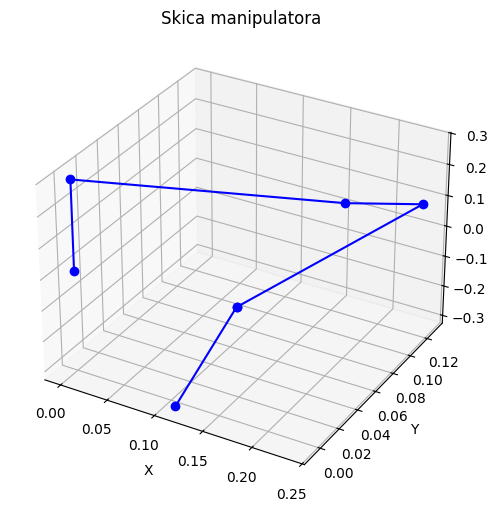

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_robot(q_vals):
    T01 = Matrix(T_0_1).subs(q_vals)
    T02 = Matrix(T_0_1.dot(T_1_2)).subs(q_vals)
    T03 = Matrix(T_0_1.dot(T_1_2).dot(T_2_3)).subs(q_vals)
    T04 = Matrix(T_0_1.dot(T_1_2).dot(T_2_3).dot(T_3_4)).subs(q_vals)
    T05 = Matrix(T_0_1.dot(T_1_2).dot(T_2_3).dot(T_3_4).dot(T_4_5)).subs(q_vals)
    T06 = Matrix(T).subs(q_vals)

    points = [
        [0,0,0],
        list(np.array(T01[:3,3], dtype=float).flatten()),
        list(np.array(T02[:3,3], dtype=float).flatten()),
        list(np.array(T03[:3,3], dtype=float).flatten()),
        list(np.array(T04[:3,3], dtype=float).flatten()),
        list(np.array(T05[:3,3], dtype=float).flatten()),
        list(np.array(T06[:3,3], dtype=float).flatten()),
    ]
    points = np.array(points)

    fig = plt.figure(figsize=(6,6))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot(points[:,0], points[:,1], points[:,2], '-o', color='blue')

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title("Skica manipulatora")
    plt.show()

# Primjer: proizvoljni kutovi
q_example = {q1:0.5, q2:0.7, q3:-0.2, q4:1.0, q5:-0.5, q6:0.8}
plot_robot(q_example)